In [9]:
import sqlite3

DB_NAME = "transit_analysis_comparison.db"

def create_database():
    conn = sqlite3.connect(DB_NAME)
    cur = conn.cursor()

    # 既存テーブルがあれば削除して初期化
    cur.execute("DROP TABLE IF EXISTS routes")
    
    # テーブル作成
    # area: 関東/関西, start_station: 東京/大阪, destination: 目的地
    cur.execute("""
        CREATE TABLE routes (
            id INTEGER PRIMARY KEY AUTOINCREMENT,
            area TEXT,
            start_station TEXT,
            destination TEXT,
            fare INTEGER,
            duration INTEGER,
            transfer INTEGER,
            distance REAL,
            cost_per_km REAL,
            time_per_km REAL
        )
    """)
    
    conn.commit()
    conn.close()
    print(f"Database '{DB_NAME}' created successfully.")

if __name__ == "__main__":
    create_database()

Database 'transit_analysis_comparison.db' created successfully.


In [10]:
import sqlite3
import time
import requests
from bs4 import BeautifulSoup
from urllib.parse import quote
import re
import random

# ==========================================
# 設定とリスト作成
# ==========================================
DB_NAME = "transit_analysis_comparison.db"
BASE_URL = "https://transit.yahoo.co.jp/search/result"
HEADERS = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36"}

# 分析用駅リスト（ランダムに選定された主要駅）
TOKYO_DESTS = ["横浜", "大宮", "八王子", "千葉", "立川", "町田", "浦和", "川崎", "柏", "藤沢", "取手", "木更津", "成田", "小田原", "熊谷"]
OSAKA_DESTS = ["京都", "神戸三宮", "奈良", "和歌山市", "宝塚", "姫路", "大津", "堺", "高槻", "明石", "枚方市", "河内長野", "近鉄名古屋", "天理", "生駒"]

# 全タスクを生成
tasks = []
for d in TOKYO_DESTS:
    tasks.append({"from": "東京", "to": d, "area": "関東"})
for d in OSAKA_DESTS:
    tasks.append({"from": "大阪", "to": d, "area": "関西"})

# シャッフルしてランダム性を出す（特定のエリアにリクエストが集中しないようにする）
random.shuffle(tasks)

# ==========================================
# スクレイピング関数
# ==========================================
def fetch_transit_data(start_station, dest_station, area):
    url = f"{BASE_URL}?from={quote(start_station)}&to={quote(dest_station)}"
    print(f"Fetching [{area}]: {start_station} -> {dest_station}...")
    
    try:
        r = requests.get(url, headers=HEADERS)
        soup = BeautifulSoup(r.text, "html.parser")
        route_summary = soup.find("div", class_="routeSummary")
        
        if not route_summary:
            return None

        # テキスト抽出と正規表現による数値化
        time_text = route_summary.select_one("li.time").get_text()
        duration = int(re.search(r'(\d+)分', time_text).group(1))

        fare_text = route_summary.select_one("li.fare").get_text()
        fare = int(re.search(r'([\d,]+)円', fare_text).group(1).replace(",", ""))

        transfer_text = route_summary.select_one("li.transfer").get_text()
        transfer = 0 if "直通" in transfer_text else int(re.search(r'\d+', transfer_text).group())

        distance_tag = route_summary.select_one("li.distance")
        distance = 0.0
        if distance_tag:
            dist_match = re.search(r'([\d\.]+).?km', distance_tag.get_text())
            if dist_match:
                distance = float(dist_match.group(1))

        # 指標計算
        cost_per_km = round(fare / distance, 2) if distance > 0 else 0
        time_per_km = round(duration / distance, 2) if distance > 0 else 0

        return (area, start_station, dest_station, fare, duration, transfer, distance, cost_per_km, time_per_km)

    except Exception as e:
        print(f"  [Error] {dest_station}: {e}")
        return None

def save_to_db(data_list):
    conn = sqlite3.connect(DB_NAME)
    cur = conn.cursor()
    cur.executemany("""
        INSERT INTO routes (area, start_station, destination, fare, duration, transfer, distance, cost_per_km, time_per_km) 
        VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?)
    """, data_list)
    conn.commit()
    conn.close()

# ==========================================
# メイン実行
# ==========================================
if __name__ == "__main__":
    all_results = []
    
    for task in tasks:
        result = fetch_transit_data(task["from"], task["to"], task["area"])
        if result:
            all_results.append(result)
        
        # サーバー負荷対策。大量に取得する場合は3〜5秒を推奨。
        time.sleep(3)

    if all_results:
        save_to_db(all_results)
        print(f"\n全{len(all_results)}件のデータを保存しました。分析を開始できます。")

Fetching [関西]: 大阪 -> 堺...
Fetching [関東]: 東京 -> 柏...
Fetching [関西]: 大阪 -> 奈良...
Fetching [関西]: 大阪 -> 京都...
Fetching [関東]: 東京 -> 町田...
Fetching [関東]: 東京 -> 小田原...
Fetching [関西]: 大阪 -> 大津...
Fetching [関西]: 大阪 -> 高槻...
Fetching [関東]: 東京 -> 浦和...
Fetching [関西]: 大阪 -> 宝塚...
Fetching [関東]: 東京 -> 横浜...
Fetching [関西]: 大阪 -> 生駒...
Fetching [関西]: 大阪 -> 近鉄名古屋...
Fetching [関東]: 東京 -> 成田...
Fetching [関東]: 東京 -> 川崎...
Fetching [関東]: 東京 -> 立川...
Fetching [関東]: 東京 -> 八王子...
Fetching [関東]: 東京 -> 大宮...
Fetching [関西]: 大阪 -> 枚方市...
Fetching [関西]: 大阪 -> 天理...
Fetching [関西]: 大阪 -> 河内長野...
Fetching [関東]: 東京 -> 熊谷...
Fetching [関西]: 大阪 -> 姫路...
Fetching [関西]: 大阪 -> 和歌山市...
Fetching [関東]: 東京 -> 藤沢...
Fetching [関西]: 大阪 -> 神戸三宮...
Fetching [関東]: 東京 -> 千葉...
Fetching [関東]: 東京 -> 取手...
Fetching [関東]: 東京 -> 木更津...
Fetching [関西]: 大阪 -> 明石...

全30件のデータを保存しました。分析を開始できます。


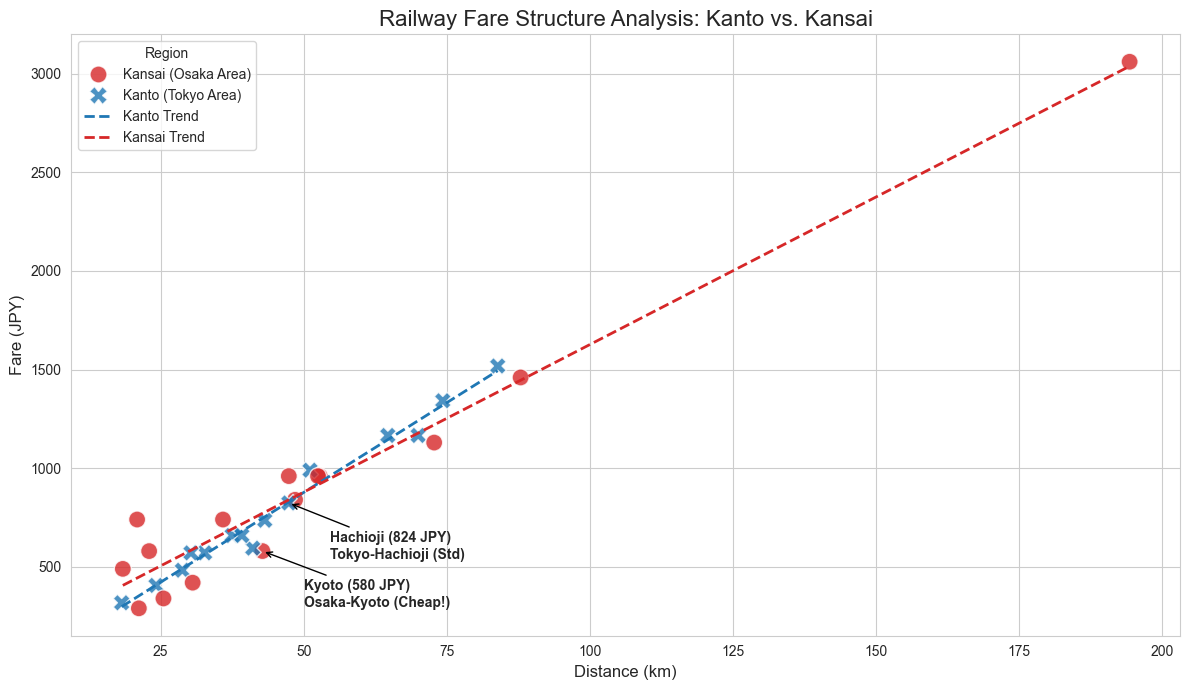

In [28]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Load Data [cite: 37]
conn = sqlite3.connect('transit_analysis_comparison.db')
df = pd.read_sql_query("SELECT * FROM routes", conn)
conn.close()

# 2. Map Japanese labels to Roman alphabet for display
area_map = {'関東': 'Kanto (Tokyo Area)', '関西': 'Kansai (Osaka Area)'}
df['area_en'] = df['area'].map(area_map)

# Station name mapping for annotations
station_map = {
    '東京': 'Tokyo', '大阪': 'Osaka', 
    '京都': 'Kyoto', '八王子': 'Hachioji'
}

# 3. Plot Configuration
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")

# 4. Scatter Plot [cite: 38, 61, 62, 63, 64, 65, 66]
scatter = sns.scatterplot(
    data=df, x='distance', y='fare', hue='area_en', style='area_en', 
    s=150, alpha=0.8, palette={'Kanto (Tokyo Area)': '#1f77b4', 'Kansai (Osaka Area)': '#d62728'}
)

# 5. Regression Lines
for area_val, label_en, color in zip(['関東', '関西'], ['Kanto', 'Kansai'], ['#1f77b4', '#d62728']):
    subset = df[df['area'] == area_val]
    if not subset.empty:
        z = np.polyfit(subset['distance'], subset['fare'], 1)
        p = np.poly1d(z)
        x_range = np.linspace(subset['distance'].min(), subset['distance'].max(), 100)
        plt.plot(x_range, p(x_range), color=color, linestyle='--', linewidth=2, label=f'{label_en} Trend')

# 6. Annotations (Mapping names to English) [cite: 63, 66]
annotations = [
    ('大阪', '京都', 'Osaka-Kyoto (Cheap!)'),
    ('東京', '八王子', 'Tokyo-Hachioji (Std)')
]

for start_jp, dest_jp, note in annotations:
    target = df[(df['start_station'] == start_jp) & (df['destination'] == dest_jp)]
    if not target.empty:
        dest_en = station_map.get(dest_jp, dest_jp)
        plt.annotate(
            f"{dest_en} ({int(target.iloc[0]['fare'])} JPY)\n{note}",
            xy=(target.iloc[0]['distance'], target.iloc[0]['fare']),
            xytext=(30, -40), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=10, fontweight='bold'
        )

# English Labels
plt.title('Railway Fare Structure Analysis: Kanto vs. Kansai', fontsize=16)
plt.xlabel('Distance (km)', fontsize=12)
plt.ylabel('Fare (JPY)', fontsize=12)
plt.legend(title='Region', fontsize=10)

plt.tight_layout()
plt.show()

In [31]:
import sqlite3
import pandas as pd

class TransitReportGenerator:
    """鉄道運賃の比較レポートを生成するクラス"""
    
    def __init__(self, db_path):
        self.db_path = db_path

    def get_specific_route(self, area, destination):
        """
        入力（エリアと目的地）に応じて、DBから動的にデータを取得する関数。
        SQLクエリのパラメータ（?）を使用して、入力に応じた柔軟な抽出を行う。
        """
        conn = sqlite3.connect(self.db_path)
        # クエリ発行によるデータ取得
        query = "SELECT area, start_station, destination, fare, distance, cost_per_km FROM routes WHERE area = ? AND destination = ?"
        df = pd.read_sql_query(query, conn, params=(area, destination))
        conn.close()
        return df

    def print_comparison_table(self):
        """
        関東（八王子）と関西（京都）を比較し、
        分析レポートの「3-②」に相当する数値を動的に出力する関数。
        """
        # クラス内関数を呼び出してデータを動的に取得
        kanto_data = self.get_specific_route('関東', '八王子')
        kansai_data = self.get_specific_route('関西', '京都')

        if not kanto_data.empty and not kansai_data.empty:
            # データの結合とフォーマット
            comparison_df = pd.concat([kanto_data, kansai_data], ignore_index=True)
            comparison_df.columns = ['Region', 'Start', 'End', 'Fare(JPY)', 'Dist(km)', 'JPY/km']
            
            # レポートの出力
            print("=== Analysis Report 3-ii: Representative Route Comparison ===")
            print("-" * 65)
            print(comparison_df.to_string(index=False))
            print("-" * 65)
            
            # 動的な分析メッセージ
            k_fare = kanto_data['fare'].iloc[0]
            o_fare = kansai_data['fare'].iloc[0]
            diff = k_fare - o_fare
            print(f"Observation: Kansai is {diff} JPY cheaper than Kanto for similar distances.")
        else:
            print("Error: Required data not found in the database. Please check the DB content.")

# --- 実行セクション ---
# クラスのインスタンス化
report = TransitReportGenerator('transit_analysis_comparison.db')
# 入力に応じた動的な比較レポートの生成
report.print_comparison_table()

=== Analysis Report 3-ii: Representative Route Comparison ===
-----------------------------------------------------------------
Region Start End  Fare(JPY)  Dist(km)  JPY/km
    関東    東京 八王子        824      47.4   17.38
    関西    大阪  京都        580      42.8   13.55
-----------------------------------------------------------------
Observation: Kansai is 244 JPY cheaper than Kanto for similar distances.
